# Project 7 - Hospital Patient & Encounter Analysis

**Name:** Marcello Velame

**Domain:** Healthcare

For Tableau Dashboards: https://public.tableau.com/app/profile/marcello.velame/viz/Book2_project_7/StaysandReadmission

## Executive Summary

### Objectives

* Assess the quality of hospital visits, departments and patients data.

* Clean and prepare the datasets for analysis.

* Build a SQLite database and perform SQL joins.

* Engineer new features to support analysis.

* Analyze merged DataFrames using Pandas, statistics and visualizations.

* Answer key business questions and provide recommendations.

### Key Findings

* Average length of stay (LOS) varies substantially by department, from 1.7 days (Emergency) to 6.7 days (Oncology), nearly a 4x difference. A one-way ANOVA confirmed that the differences between departments are statistically significant (F(5, 1747) = 493.01, p < .001). Tukey HSD post-hoc testing showed that Oncology differs significantly from every other department in average LOS.

* The overall average LOS across all departments is 3.6 days.

* Oncology combines the longest stays with the largest share of total charges (~29%), while Emergency has the highest visit volume (316 visits) but the shortest stays.

* The highest-volume departments are Emergency (316 visits) and General Medicine (262 visits).

* Roughly half of total charges come from two departments: Oncology (~29%) and Cardiology (~21%), together ~$4.9M of $9.64M (~50%).

* Private insurance is the largest single payer, accounting for $4.14M (~43%) of total charges. Public insurance combined (Medicare $3.07M and Medicaid ~$1.5M) accounts for ~$4.6M (~48%). Leaving ~759,126.01 or ~8% with uninsured patients. The remaining ~$151K in charges comes from visits with missing insurance_type — see Business Question 3 for detail.

* Patient ages are symmetrically distributed (mean 48.8, median 49.0), with half of visits from patients aged 36 to 61.

* Length of stay shows a weak positive correlation with age (r = 0.21, p < .001): older patients tend to stay somewhat longer, but age explains only a small share of the variation in LOS. Averages rise between roughly ages 10 and 89, then dip beyond 89, likely reflecting the small number of patients in that range. This is an association only; age is likely intertwined with department mix (e.g., older patients in Oncology and Cardiology).

* The overall 30-day readmission rate is ~12.8% (224 of 1,753 visits). This is slightly below typical all-payer national estimates (~13-15%) and below the 15-20% often reported for Medicare patients, though differences in patient mix limit direct comparison.

* A chi-square test found no statistically significant association between smoker status and 30-day readmission, χ²(1, N = 1,753) = 1.59, p = .207, Cramér's V = .03. Readmission was 14.9% among smokers vs. 12.2% among non-smokers (OR = 1.26, 95% CI [0.90, 1.76]). Because the interval includes 1.0, the data are consistent with no difference, though a modest increase in risk cannot be ruled out.


### Data Quality Issues 

* 6 patients (26 visits, after merging to visit-level) missing insurance_type, accounting for $151,221.16 in charges not reflected in the insurance-type breakdown.

* No duplicate records anywhere.

* 10 total_charge fields left blank.


### Recommendations

* Smoker status doesn't seem to predict 30-day readmission, so smoking-focused intervention is not well supported by this analysis. Management may wish to look at other factors, such as discharge planning, followup schedule, or diagnosis, as a more promising issues to reducing readmission.

* For planning considerations, department averages show older patients concentrated in Oncology and Cardiology, the departments with the longest stays. Assuming the aging population continues to grow, the demands in those departments, may grow faster than Emergency and General Medicine (departments with the most visits and shorter LOS). 

* Total charges are split across private insurance ($4.14M, ~43%) and public insurance, Medicare and Medicaid combined (~$4.6M, ~48%). However, "charges" aren't the same as collected revenue. Most payers, private and public alike, pay negotiated or set rates below billed charges (private insurers through contracted rates, Medicare and Medicaid through fixed fee schedules). So this payer mix shows where billing volume comes from, not where actual net revenue lands. A follow-up analysis using net revenue by payer, if that data becomes available, would give management a more accurate financial picture than charges alone.

* Oncology (6.7-day average LOS) and Emergency (1.7-day average LOS, highest volume at 316 visits) need very different resourcing. Oncology's numbers point toward bed and long-stay staffing capacity; Emergency's point toward throughput and triage efficiency rather than bed capacity.


### Limitations

* Correlation does not establish causation.

* There was no sufficient information within the data to extract revenue collected.

* Results are limited to the available data and time period.

* Additional financial data would strengthen future analyses.

### Assumptions 

* Missing 6 patient insurance types (26 visits, after merging to visit-level) - These records were kept and unchanged, with the assumption they contained useful information for the analysis.

* Missing 10 total charges - Again, these records were kept and unchanged, with the assumption they contained useful information for the analysis.



### Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 as sql
from scipy import stats
from scipy.stats import chi2_contingency


### Helper Functions

In [2]:
# Function to strip spaces and set title to columns
def clean_text(df, columns):
    for col in columns:
        df[col] = df[col].str.strip().str.title()
    return df

### Loading .CSV Files

In [3]:
patients = pd.read_csv('patients.csv')
visits = pd.read_csv('visits.csv')
departments = pd.read_csv('departments.csv')

# Data Quality Assessment

### patients.csv

In [4]:
patients.head()

,patient_id,age,sex,insurance_type,smoker,registration_date
0,1001,52,Male,Private,Yes,2021-10-29
1,1002,58,Female,Private,Yes,2024-03-18
2,1003,47,Male,Private,No,2021-07-14
3,1004,34,Male,Private,Yes,2024-09-11
4,1005,43,Female,Private,No,2022-06-07


In [5]:
patients.shape

(500, 6)

In [6]:
patients.dtypes 

patient_id           int64
age                  int64
sex                    str
insurance_type         str
smoker                 str
registration_date      str
dtype: object

In [7]:
patients.isnull().sum()

patient_id           0
age                  0
sex                  0
insurance_type       6
smoker               0
registration_date    0
dtype: int64

In [8]:
patients.duplicated().sum()

np.int64(0)

In [9]:
patients = clean_text(patients, ['sex', 'insurance_type', 'smoker'])

In [10]:
patients.head(10)

,patient_id,age,sex,insurance_type,smoker,registration_date
0,1001,52,Male,Private,Yes,2021-10-29
1,1002,58,Female,Private,Yes,2024-03-18
2,1003,47,Male,Private,No,2021-07-14
3,1004,34,Male,Private,Yes,2024-09-11
4,1005,43,Female,Private,No,2022-06-07
5,1006,32,Female,Medicare,No,2023-05-19
6,1007,53,Male,Private,No,2022-08-20
7,1008,79,Female,Private,No,2022-05-25
8,1009,42,Male,Private,No,2024-06-16
9,1010,40,Female,Medicare,No,2022-06-03


In [11]:
patients['registration_date'] = pd.to_datetime(patients['registration_date'])
patients.dtypes

patient_id                    int64
age                           int64
sex                             str
insurance_type                  str
smoker                          str
registration_date    datetime64[us]
dtype: object

### Observations: 

A first look at the patients table revealed good quality data, with only date as string type and 6 patient insurance_type missing (26 visits, after merging to visit-level). Since the rest of the data gives me no information that would help me infer the missing fields, they were left blank, since these are real patients with real visits to the hospital. The dates were changed to datetime format.

### visits.csv

In [12]:
visits.head()

,visit_id,patient_id,department_id,admission_date,discharge_date,length_of_stay_days,total_charges,readmitted_30d
0,5001,1001,5,2023-03-19,2023-03-22,3,4000.28,No
1,5002,1001,5,2024-11-06,2024-11-08,2,2972.60,No
2,5003,1001,2,2022-05-19,2022-05-21,2,4316.94,No
3,5004,1001,3,2023-05-10,2023-05-12,2,3991.12,No
4,5005,1001,5,2023-03-31,2023-04-04,4,5608.74,No


In [13]:
visits.shape

(1753, 8)

In [14]:
visits.dtypes

visit_id                 int64
patient_id               int64
department_id            int64
admission_date             str
discharge_date             str
length_of_stay_days      int64
total_charges          float64
readmitted_30d             str
dtype: object

In [15]:
visits.duplicated().sum()

np.int64(0)

In [16]:
date_cols = ['admission_date', 'discharge_date']
for col in date_cols:
    visits[col] = pd.to_datetime(visits[col])
visits.dtypes

visit_id                        int64
patient_id                      int64
department_id                   int64
admission_date         datetime64[us]
discharge_date         datetime64[us]
length_of_stay_days             int64
total_charges                 float64
readmitted_30d                    str
dtype: object

In [17]:
visits.isnull().sum()

visit_id                0
patient_id              0
department_id           0
admission_date          0
discharge_date          0
length_of_stay_days     0
total_charges          10
readmitted_30d          0
dtype: int64

In [18]:
visits = clean_text(visits, ['readmitted_30d'])

In [19]:
visits.head(10)

,visit_id,patient_id,department_id,admission_date,discharge_date,length_of_stay_days,total_charges,readmitted_30d
0,5001,1001,5,2023-03-19,2023-03-22,3,4000.28,No
1,5002,1001,5,2024-11-06,2024-11-08,2,2972.60,No
2,5003,1001,2,2022-05-19,2022-05-21,2,4316.94,No
3,5004,1001,3,2023-05-10,2023-05-12,2,3991.12,No
4,5005,1001,5,2023-03-31,2023-04-04,4,5608.74,No
5,5006,1001,3,2022-11-19,2022-11-20,1,3198.08,No
6,5007,1002,4,2023-11-28,2023-11-30,2,2624.55,No
7,5008,1002,3,2022-08-31,2022-09-06,6,8662.37,No
8,5009,1002,4,2023-07-10,2023-07-12,2,2778.63,No
9,5010,1002,2,2022-03-28,2022-03-30,2,4236.98,No


### Observations:

The visits table show very good quality data, with no duplicates. There are 10 records missing in the columns total_charges, which were left blank due to the fact the these records contain useful information besides total_charges. admission_date & discharge_date were reset as datetime format.

### Departments

In [20]:
departments.head(6)

,department_id,department_name,building
0,1,Cardiology,A
1,2,Orthopedics,A
2,3,General Medicine,B
3,4,Pediatrics,C
4,5,Emergency,Emergency Wing
5,6,Oncology,B


In [21]:
departments.dtypes

department_id      int64
department_name      str
building             str
dtype: object

In [22]:
departments = clean_text(departments, ['department_name', 'building'])

In [23]:
departments.head(6)

,department_id,department_name,building
0,1,Cardiology,A
1,2,Orthopedics,A
2,3,General Medicine,B
3,4,Pediatrics,C
4,5,Emergency,Emergency Wing
5,6,Oncology,B


### Observations:

The departments table is simply a list of the six departments of the hospital and required no intervention in the quality of data, except for making sure there were no spaces before or after the fields. 

# Merging the Files with SQL

In [24]:
conn = sql.connect('project7.db')
patients.to_sql('patients', conn, if_exists='replace', index=False)
visits.to_sql('visits', conn, if_exists='replace', index=False)
departments.to_sql('departments', conn, if_exists='replace', index=False)

6

In [25]:
query = '''
SELECT v.*,
       p.age, p.sex, p.insurance_type, p.smoker, p.registration_date,
       d.department_name, d.building
FROM visits v
LEFT JOIN patients p ON v.patient_id = p.patient_id
LEFT JOIN departments d ON v.department_id = d.department_id
'''
df = pd.read_sql_query(query, conn)

In [26]:
df.head()

,visit_id,patient_id,department_id,admission_date,discharge_date,length_of_stay_days,total_charges,readmitted_30d,age,sex,insurance_type,smoker,registration_date,department_name,building
0,5001,1001,5,2023-03-19 00:00:00,2023-03-22 00:00:00,3,4000.28,No,52,Male,Private,Yes,2021-10-29 00:00:00,Emergency,Emergency Wing
1,5002,1001,5,2024-11-06 00:00:00,2024-11-08 00:00:00,2,2972.60,No,52,Male,Private,Yes,2021-10-29 00:00:00,Emergency,Emergency Wing
2,5003,1001,2,2022-05-19 00:00:00,2022-05-21 00:00:00,2,4316.94,No,52,Male,Private,Yes,2021-10-29 00:00:00,Orthopedics,A
3,5004,1001,3,2023-05-10 00:00:00,2023-05-12 00:00:00,2,3991.12,No,52,Male,Private,Yes,2021-10-29 00:00:00,General Medicine,B
4,5005,1001,5,2023-03-31 00:00:00,2023-04-04 00:00:00,4,5608.74,No,52,Male,Private,Yes,2021-10-29 00:00:00,Emergency,Emergency Wing


In [27]:
date_cols = ['admission_date', 'discharge_date', 'registration_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])
df.dtypes

visit_id                        int64
patient_id                      int64
department_id                   int64
admission_date         datetime64[us]
discharge_date         datetime64[us]
length_of_stay_days             int64
total_charges                 float64
readmitted_30d                    str
age                             int64
sex                               str
insurance_type                    str
smoker                            str
registration_date      datetime64[us]
department_name                   str
building                          str
dtype: object

In [28]:
df.head()

,visit_id,patient_id,department_id,admission_date,discharge_date,length_of_stay_days,total_charges,readmitted_30d,age,sex,insurance_type,smoker,registration_date,department_name,building
0,5001,1001,5,2023-03-19,2023-03-22,3,4000.28,No,52,Male,Private,Yes,2021-10-29,Emergency,Emergency Wing
1,5002,1001,5,2024-11-06,2024-11-08,2,2972.60,No,52,Male,Private,Yes,2021-10-29,Emergency,Emergency Wing
2,5003,1001,2,2022-05-19,2022-05-21,2,4316.94,No,52,Male,Private,Yes,2021-10-29,Orthopedics,A
3,5004,1001,3,2023-05-10,2023-05-12,2,3991.12,No,52,Male,Private,Yes,2021-10-29,General Medicine,B
4,5005,1001,5,2023-03-31,2023-04-04,4,5608.74,No,52,Male,Private,Yes,2021-10-29,Emergency,Emergency Wing


In [29]:
df.shape

(1753, 15)

In [30]:
df.isnull().sum()

visit_id                0
patient_id              0
department_id           0
admission_date          0
discharge_date          0
length_of_stay_days     0
total_charges          10
readmitted_30d          0
age                     0
sex                     0
insurance_type         26
smoker                  0
registration_date       0
department_name         0
building                0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

### Merging Observations:

The merging rationale was to establish the table visits as the anchor table, and LEFT JOIN patients and departments. The merging of the tables, however, tried to generate a time stamp for the date columns. The fix was to reset these columns to datetime. A quick check of row count, after the merge, shows the same number of rows of visits (anchor table). It also reveals the the 10 blank total charges and the now 26 blank insurance types are part of the merged DataFrame. These will not be imputed or excluded due to the fact that they cannot be inferred and the fact the record contains useful information for the analysis. 

# EDA 

In [32]:
df['length_of_stay_days'].describe().round(1)

count    1753.0
mean        3.6
std         2.3
min         0.0
25%         2.0
50%         3.0
75%         5.0
max        11.0
Name: length_of_stay_days, dtype: float64

In [33]:
df['total_charges'].describe().round(2)

count     1743.00
mean      5531.70
std       2793.63
min        925.89
25%       3321.58
50%       5123.58
75%       7365.64
max      15799.70
Name: total_charges, dtype: float64

### Observations:

Mean and median are close for both columns above indicating that the data is roughly symmetric with a slight pull to the right. The mean is therefore a reasonable measure of typical value for both columns. 


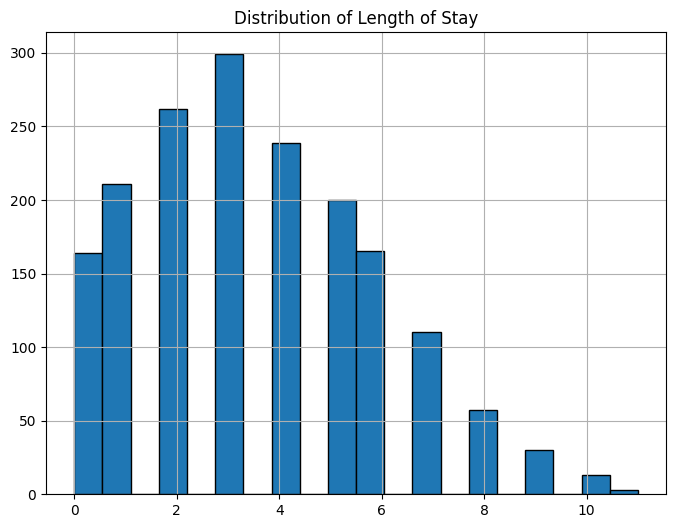

In [34]:

plt.figure(figsize=(8, 6))
df['length_of_stay_days'].hist(bins=20, edgecolor='black')
plt.title('Distribution of Length of Stay')
plt.show()

### Observations:

The histogram confirms the distribution is single-peaked, roughly symmetric with a slight right-skew, and with no extreme outliers for the length of stay column.

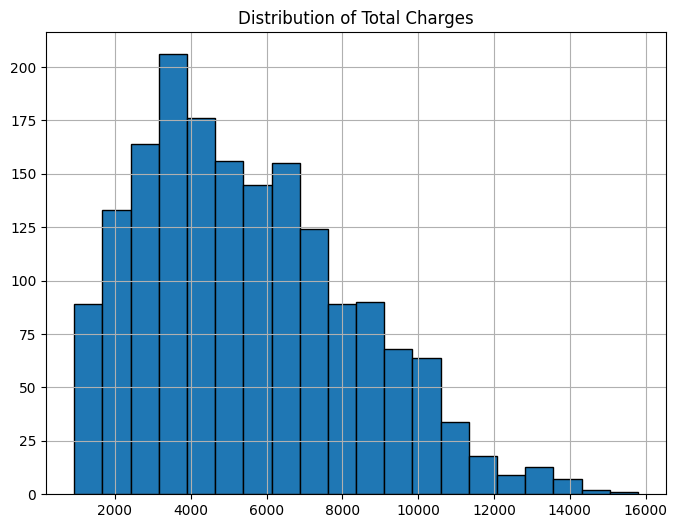

In [35]:
plt.figure(figsize=(8, 6))
df['total_charges'].hist(bins=20, edgecolor='black')
plt.title('Distribution of Total Charges')
plt.show()

### Observations:

Although the skewing is slightly stronger in the distribution of total charges due to a minority of high-cost visits, it is still moderate and consistent with the mean (5,531.70) vs. median (5123.58), with no extreme outliers, and one single peak.

In [36]:
df['age'].describe().round(1)

count    1753.0
mean       48.8
std        18.2
min         1.0
25%        36.0
50%        49.0
75%        61.0
max        98.0
Name: age, dtype: float64

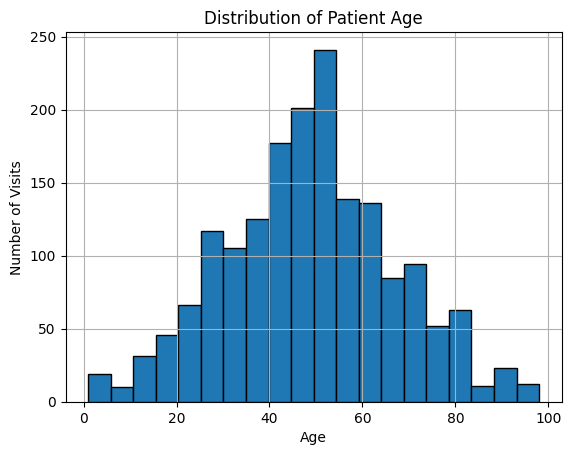

In [37]:
df['age'].hist(bins=20, edgecolor='black')
plt.title('Distribution of Patient Age')
plt.xlabel('Age'); plt.ylabel('Number of Visits')
plt.show()

### Observations:

Ages are within a reasonable range (min. 1 - max. 98), and roughly symmetricly distributed according to the mean (48.8) and median (49.0). Moreover, 25% of visits are of patients 36 and under and 25% 61 and over. There are no invalid values (zeros or negatives).

In [38]:
df['department_name'].value_counts()

department_name
Emergency           316
Cardiology          297
Oncology            296
Pediatrics          293
Orthopedics         289
General Medicine    262
Name: count, dtype: int64

In [39]:
df['insurance_type'].value_counts()

insurance_type
Private      748
Medicare     558
Medicaid     275
Uninsured    146
Name: count, dtype: int64

In [40]:
df['readmitted_30d'].value_counts()

readmitted_30d
No     1529
Yes     224
Name: count, dtype: int64

In [41]:
df['smoker'].value_counts()

smoker
No     1405
Yes     348
Name: count, dtype: int64

### Observations:

All six categories are well represented, visits (262-316), supporting reliable department comparisons and ANOVA test. Insurance is usable but uneven (private: 748 to uninsured: 146). The readmission rate is roughly 12.8%, and smokers make up about 20% of the visits. All categories are clean.

# Business Questions

### 1. Which departments have the highest patient volume and the longest average length of stay (LOS)?

In [42]:
department_volume = df.groupby('department_name')['visit_id'].count().sort_values(ascending=False)
print(department_volume)

department_name
Emergency           316
Cardiology          297
Oncology            296
Pediatrics          293
Orthopedics         289
General Medicine    262
Name: visit_id, dtype: int64


### Observations:

The departmental volume is evenly distributed, with a ranking from 262 (General Medicine) to 316 (Emergency), 15% and 18% respectively. No department dominates or is underrepresented and the later ANOVA test rest on balanced numbers.

In [43]:
#Department and hospital average LOS
dept_los = (df.groupby("department_name")["length_of_stay_days"]
              .agg(patients="count", avg_los="mean")
              .round(1)
              .sort_values("avg_los", ascending=False))

overall_los = df["length_of_stay_days"].mean()

print(dept_los)
print(f"\nOverall average LOS: {overall_los:.1f} days")

                  patients  avg_los
department_name                    
Oncology               296      6.7
Cardiology             297      4.7
Orthopedics            289      3.8
General Medicine       262      2.7
Emergency              316      1.7
Pediatrics             293      1.7

Overall average LOS: 3.6 days


### Observations:

Average length of stay varies substantially by department — from ~1.7 days (Emergency, Pediatrics) up to 6.7 days (Oncology), nearly 4x the shortest. Oncology and Cardiology have the longest stays; Emergency and Pediatrics the shortest." That captures the full picture, not just Oncology. This means that the ANOVA is expected to reject the null hypothesis. 

### 2. What is the overall 30-day readmission rate, and how does it vary by department?

Answer for part A of the questions - What is the overall 30-day readmission rate? 

The overall 30-day readmission rate is ~12.8%, 224 out of 1,753 visits. This percentage sits slightly below national figures in the US (15 - 20%). In comparison, ~12.8% is a realistic percentage for a general hospital population. Since high readmission rates signal problems, it is good to have a below the average rate. The rate of ~12.8% serves as the baseline against which department-level and smoker-status readmission rates are compared — groups exceeding it warrant closer attention.

In [44]:
df['readmitted_flag'] = (df['readmitted_30d'] == 'Yes').astype(int)
df.groupby('department_name')['readmitted_flag'].mean().sort_values(ascending=False).round(2)

department_name
Emergency           0.22
Oncology            0.19
Pediatrics          0.13
General Medicine    0.08
Cardiology          0.07
Orthopedics         0.06
Name: readmitted_flag, dtype: float64

Answer for part B - How does it vary by department?

Orthopedics (6%), Cardiology (7%), General Medicine (8%) are all below the hospital average (~12.8%). While Pediatrics (13%) is slightly above the hospital average, and Oncology (19%) and Emergency (22%) are closer to the upper range of the national average. Upper management may wish to further investigate the reasons why Emergency and Oncology have the higher rates of readmission. However, perhaps Emergency and Oncology are serving higher-acuity, sicker population would naturally readmit more. Notably, Emergency and Oncology sit at opposite ends of the length-of-stay spectrum (1.7 vs 6.7 days) yet share the highest readmission rates — suggesting readmission here is driven by patient acuity rather than short stays alone.  
The spread from 6% (Orthopedics) to 22% (Emergency) is more than 3X the spread. Whether these department-level differences are statistically significant could be tested formally. 


### 3. How do total charges break down by department and by insurance type?

Answer Part A - How do total charges break down by department?

Oncology generated 2.86 M (29% of 9.64 M) in charges despite not having the most visits. Emergency had the most visits and ranked 5th in charges with 10% of total billing. The data suggest the cause to be those long stays per visit for oncology patients (average 6.7 days). While Emergency visits are much shorter  (1.7 days per visit) which end up being cheaper. One more point is that roughly 50% of the billing generated by the hospital comes from two departments Oncology (29%) and Cardiology (21%). The remaining 4 departments, Ortho, General Medicine, Emergency and Pediatrics, together are responsible for the other ~50%. As mentioned in the data cleaning section, there are 10 records missing total_charges, so these totals should be treated as estimations.

Answer Par B - How do total charges break down by insurance type?

Private insurance is the largest single payer at $4.14M (43%), but public insurance (Medicare $3.07M + Medicaid $1.51M) together accounts for ~$4.59M (48%) — the largest payer bloc overall. Uninsured visits generated $759K (8%) in charges, which represents potential collection risk since self-pay balances are often difficult to recover. Note that these are billed charges, not collected revenue; since Medicare and Medicaid typically reimburse below private rates, actual collections likely skew lower than these totals suggest. As the per-visit averages below show, the charge per visit is similar across insurance types — so the differences in totals mainly reflect visit volume. Actual collected amounts would differ, since each payer reimburses at its own rate.

In [45]:
df.groupby('department_name')['total_charges'].sum().sort_values(ascending=False)

department_name
Oncology            2860575.17
Cardiology          2063062.58
Orthopedics         1645206.36
General Medicine    1155090.13
Emergency            982500.36
Pediatrics           935325.67
Name: total_charges, dtype: float64

In [46]:
total = df['total_charges'].sum()
print(total)

9641760.27


In [47]:
# How many rows are missing insurance_type, and what do they total in charges?
missing_insurance = df[df['insurance_type'].isnull()]

print(f"Rows missing insurance_type: {len(missing_insurance)}")
print(f"Total charges in those rows: {missing_insurance['total_charges'].sum():,.2f}")

# Confirm this fully explains the gap between the two totals
overall_total = df['total_charges'].sum()
insurance_grouped_total = df.groupby('insurance_type')['total_charges'].sum().sum()

print(f"\nOverall total_charges: {overall_total:,.2f}")
print(f"Sum of insurance-type groups: {insurance_grouped_total:,.2f}")
print(f"Gap: {overall_total - insurance_grouped_total:,.2f}")

Rows missing insurance_type: 26
Total charges in those rows: 151,221.16

Overall total_charges: 9,641,760.27
Sum of insurance-type groups: 9,490,539.11
Gap: 151,221.16


### Observations

The insurance-type breakdown above totals $9.49M, while total charges across all visits are $9.64M. The $151,221.16 difference is fully accounted for by the 26 visits missing insurance_type (confirmed by summing total_charges for those rows), which are excluded from the insurance groupby but included in the department and overall totals.

In [48]:
df.groupby('insurance_type')['total_charges'].sum().sort_values(ascending=False)

insurance_type
Private      4143056.36
Medicare     3074823.83
Medicaid     1513532.91
Uninsured     759126.01
Name: total_charges, dtype: float64

In [49]:
df.groupby('insurance_type')['total_charges'].mean().sort_values(ascending=False).round(2)

insurance_type
Private      5583.63
Medicaid     5564.46
Medicare     5520.33
Uninsured    5199.49
Name: total_charges, dtype: float64

### 4. What does the age distribution of patients look like, and does older age associate with long stays?

Answer Part A - What does the age distribution of patients look like?

Ages are within a reasonable range (min. 1 - max. 98), and symmetricly distributed according to the mean (48.8) and median (49.0). Moreover, 25% of visits are of patients 36 and under and 25% 61 and over. There are no invalid values (zeros or negatives). As the age distribution histogram in the EDA section  confirms, age is approximately symmetrically distributed, though the older age tail shows some irregularity.

Answer Part B - Does older age associate with long stays?

### Observations:

Grouping age into decade-wide bins and comparing average length of stay per group reveals an upward trend from the 20s through the 80s, with average stay climbing from roughly 2.8 days (20-29) to a peak of 4.7 days (80-89). The 0-9 and 10-19 groups don't follow this trend as cleanly, possibly reflecting different admission patterns for pediatric care. The 90-99 group shows a slight dip from the 80-89 peak, but this bin has a notably smaller sample size (31 patients) than the other age groups, so some noise in that average is expected rather than a genuine reversal of the trend. A Pearson correlation confirmed a statistically significant but weak positive association between age and length of stay (r = 0.21, p < .001). In other words, older patients tend to stay somewhat longer, but LOS varies widely within each age group, so age explains only a small share (about 4%) of the variation in length of stay.

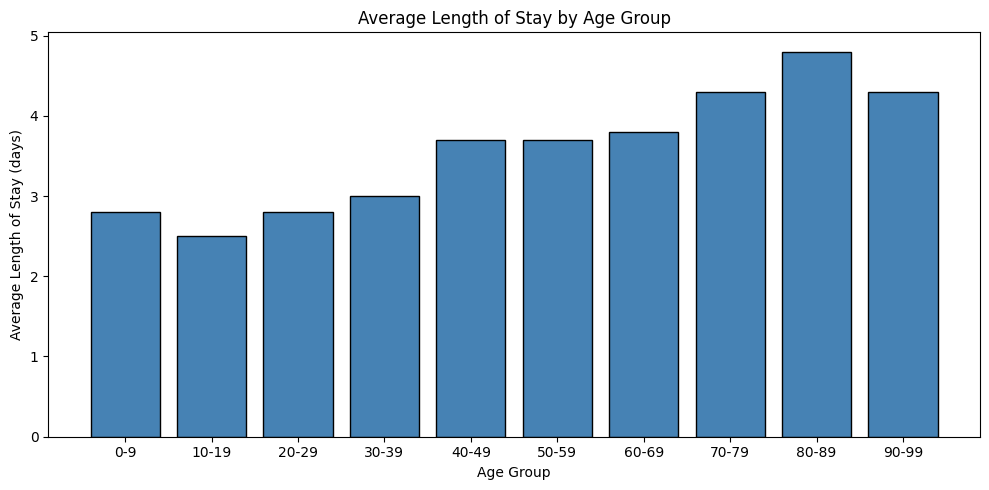

In [50]:
age_bins = [0, 9, 19, 29, 39, 49, 59, 69, 79, 89, 99]
age_labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-99']

df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

age_vs_stay = df.groupby('age_group')['length_of_stay_days'].mean().round(1)

plt.figure(figsize=(10, 5))
plt.bar(age_vs_stay.index, age_vs_stay.values, color='steelblue', edgecolor='black')
plt.title('Average Length of Stay by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Length of Stay (days)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
df['age_group'].value_counts()

age_group
50-59    380
40-49    378
30-39    268
60-69    260
20-29    149
70-79    122
10-19     75
80-89     63
90-99     31
0-9       27
Name: count, dtype: int64

In [52]:
from scipy.stats import pearsonr

r, p = pearsonr(df["age"], df["length_of_stay_days"])
print(f"r = {r:.2f}, p = {p:.4f}")

r = 0.21, p = 0.0000


### 5. Which departments drive the most total revenue (charges)?

Both Oncology (2.86M) and Cardiology (2.06M) together are responsible for 4.92M out of 9.64M in revenue, which represents ~50% of total charge by all departments. Neither department has the largest number of visits. However, Oncology has a mean stay of 6.7 and Cardiology 4.7 days, which suggests longer stays are partially responsible for larger revenue. The Emergency department, which has the largest number of visits (316), but an average stay of 1.7 days, comes in on fifth in the revenue rank, suggesting the longer stay generates more revenue than the number of visits. Question 3 shows a detailed breakdown of total charges by department.

# Statistical Analysis

### ANOVA - Does average length of stay differ significantly across departments? 

H0 - All department means are equal - p-value < 0.05

In [53]:
# Split length of stay into one array per department
groups = [group['length_of_stay_days'].values for name, group in df.groupby('department_id')]

f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 493.0102
P-value: 0.0000


F(df1, df2) = 493.01, p < 0.001

In [54]:
k = df["department_id"].nunique()      # number of departments (groups)
n = len(df)                          # total number of patients

df1 = k - 1          # between-groups degrees of freedom
df2 = n - k           # within-groups degrees of freedom

print(f"F({df1}, {df2}) = {f_stat:.2f}, p < .001")

F(5, 1747) = 493.01, p < .001


In [55]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_results = pairwise_tukeyhsd(
    endog=df['length_of_stay_days'],
    groups=df['department_id'],  # use your actual column name here
    alpha=0.05
)

print(tukey_results)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   -0.935    0.0 -1.2919 -0.5781   True
     1      3   -2.056    0.0  -2.422 -1.6899   True
     1      4  -2.9799    0.0 -3.3355 -2.6242   True
     1      5  -3.0214    0.0 -3.3704 -2.6723   True
     1      6   2.0024    0.0  1.6477  2.3572   True
     2      3   -1.121    0.0 -1.4894 -0.7525   True
     2      4  -2.0449    0.0  -2.403 -1.6868   True
     2      5  -2.0864    0.0 -2.4379 -1.7348   True
     2      6   2.9374    0.0  2.5802  3.2946   True
     3      4  -0.9239    0.0 -1.2912 -0.5567   True
     3      5  -0.9654    0.0 -1.3263 -0.6045   True
     3      6   4.0584    0.0   3.692  4.4248   True
     4      5  -0.0415 0.9994 -0.3918  0.3088  False
     4      6   4.9823    0.0  4.6264  5.3383   True
     5      6   5.0238    0.0  4.6745  5.3732   True
----------------------------------------------

In [56]:
sorted(df['department_name'].unique())

['Cardiology',
 'Emergency',
 'General Medicine',
 'Oncology',
 'Orthopedics',
 'Pediatrics']

In [57]:
df[['department_id', 'department_name']].drop_duplicates().sort_values('department_id')

,department_id,department_name
14,1,Cardiology
2,2,Orthopedics
3,3,General Medicine
6,4,Pediatrics
0,5,Emergency
10,6,Oncology


### Observations:

To test whether length of stay actually varies by department — rather than the differences 
just being random noise — the ANOVA test was used. The result (F = 493.01, p < 0.001) confirms 
that department does have a real effect on length of stay; the differences we saw in the 
earlier department comparison aren't due to chance.

Since ANOVA only tells us that a difference exists somewhere, not where, I followed up with 
Tukey's HSD test to compare each department against every other department individually. 
The results show that nearly every department pair differs significantly from one another, 
with one notable exception: Emergency and Pediatrics are not significantly different from 
each other (p = 0.999), consistent with their nearly identical average stays (1.7 days each) 
found earlier. Oncology stands out as significantly different from every other department, 
confirming it as the clear outlier with the longest average stay (6.7 days).

### Chi-square - Is there a significant association between smoker status and 30-day readmission?

In [58]:
# # Chi-Square Test of Independence
# **H0:** Smoker status and 30-day readmission are independent (no association).
# **H1:** Smoker status and 30-day readmission are associated.

# ---- EDIT THESE TO MATCH YOUR DATA ----

SMOKER_COL = "smoker"               # e.g. Yes / No
READMIT_COL = "readmitted_30d"      # e.g. Yes / No
ALPHA = 0.05



# Drop rows missing either variable so the test uses complete cases only
df = df.dropna(subset=[SMOKER_COL, READMIT_COL])
print(f"Rows used: {len(df):,}")

# Contingency table (observed counts) and row percentages
observed = pd.crosstab(df[SMOKER_COL], df[READMIT_COL])
row_pct = pd.crosstab(df[SMOKER_COL], df[READMIT_COL], normalize="index") * 100

print("Observed counts:")
print(observed, "\n")
print("Readmission rate within each smoker group (row %):")
print(row_pct.round(1))

# Run the chi-square test
chi2, p, dof, expected = chi2_contingency(observed)
expected = pd.DataFrame(expected, index=observed.index, columns=observed.columns)

print(f"\nChi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p:.4f}")

# Check the assumption: expected counts should be >= 5 in (nearly) all cells
print("\nExpected counts:")
print(expected.round(1))
pct_small = (expected < 5).to_numpy().mean() * 100
print(f"\nCells with expected count < 5: {pct_small:.0f}%  (want 0%, and no cell < 1)")

# Effect size: Cramer's V (0 = no association, 1 = perfect association)
n = observed.to_numpy().sum()
k = min(observed.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))
print(f"Cramer's V: {cramers_v:.3f}")
# Rough guide (df=1): 0.1 small, 0.3 medium, 0.5 large

# Which cells drive the result? Standardized residuals (|value| > 2 stands out)
residuals = (observed - expected) / np.sqrt(expected)
print("\nStandardized residuals:")
print(residuals.round(2))

# Odds ratio (only meaningful for a 2x2 table)
if observed.shape == (2, 2):
    a, b = observed.iloc[0].to_numpy()
    c, d = observed.iloc[1].to_numpy()
    odds_ratio = (a * d) / (b * c)
    print(f"\nOdds ratio ({observed.index[0]} vs {observed.index[1]}): {odds_ratio:.2f}")

# Conclusion
if p < ALPHA:
    print(f"\np = {p:.4f} < {ALPHA}: reject H0. There is a statistically significant "
          f"association between smoker status and 30-day readmission "
          f"(Cramer's V = {cramers_v:.2f}).")
else:
    print(f"\np = {p:.4f} >= {ALPHA}: fail to reject H0. No statistically significant "
          f"association between smoker status and 30-day readmission.")

Rows used: 1,753
Observed counts:
readmitted_30d    No  Yes
smoker                   
No              1233  172
Yes              296   52 

Readmission rate within each smoker group (row %):
readmitted_30d    No   Yes
smoker                    
No              87.8  12.2
Yes             85.1  14.9

Chi-square statistic: 1.591
Degrees of freedom:   1
p-value:              0.2072

Expected counts:
readmitted_30d      No    Yes
smoker                       
No              1225.5  179.5
Yes              303.5   44.5

Cells with expected count < 5: 0%  (want 0%, and no cell < 1)
Cramer's V: 0.030

Standardized residuals:
readmitted_30d    No   Yes
smoker                    
No              0.22 -0.56
Yes            -0.43  1.13

Odds ratio (No vs Yes): 1.26

p = 0.2072 >= 0.05: fail to reject H0. No statistically significant association between smoker status and 30-day readmission.


In [59]:
# CI confidence interval
a, b = observed.loc["Yes", "Yes"], observed.loc["Yes", "No"]   # smokers: readmitted, not readmitted
c, d = observed.loc["No", "Yes"], observed.loc["No", "No"]     # non-smokers
or_ = (a / b) / (c / d)
se = np.sqrt(1/a + 1/b + 1/c + 1/d)
lo, hi = np.exp(np.log(or_) + np.array([-1.96, 1.96]) * se)
print(f"OR (smoker vs non-smoker): {or_:.2f}  95% CI [{lo:.2f}, {hi:.2f}]")

OR (smoker vs non-smoker): 1.26  95% CI [0.90, 1.76]


### Observations:

A chi-square test of independence found no statistically significant association between smoking status and 30-day readmission,  χ²(1, N = 1,753) = 1.59,       p = .207, Cramér's V = .03 (all expected cell counts ≥ 5). The readmission rate was 14.9% among smokers and 12.2% among non-smokers, a difference of 2.7 percentage points. Smokers' odds of readmission were 1.26 times those of non-smokers (95% CI [0.90, 1.76]); because the interval includes 1.0, the data are consistent with no difference. The data therefore do not provide sufficient evidence that readmission rates differ by smoking status. This does not show that smoking has no effect: a difference of this size could plausibly arise by chance given the sample size, and the confidence interval does not rule out a modest increase in risk. The analysis did not adjust for other factors such as age, diagnosis, or length of stay, which may influence readmission. A multivariable approach, such as logistic regression, would be needed to draw firmer conclusions.

# Conclusion

This analysis identified clear patterns in length of stay, revenue concentration, and readmissions across departments, and grounded them in statistical testing rather than observation alone. The use of ANOVA, chi-square and Tukey HSD testing corroborates what the data shows and provides a higher degree of confidence for decision-making. With additional financial data, particularly on collected revenue by payer, this analysis could be extended to give management a clearer, more complete picture to guide resource and financial planning decisions.

### Tableau prep

In [60]:
df.to_csv('project_7_dashboard_export.csv', index=False)

In [61]:
df.groupby('age_group')['length_of_stay_days'].agg(['count', 'mean']).round(2)

,count,mean
age_group,,
0-9,27,2.78
10-19,75,2.55
20-29,149,2.77
30-39,268,3.01
40-49,378,3.65
50-59,380,3.71
60-69,260,3.84
70-79,122,4.34
80-89,63,4.78


**Observations:** 

Visit counts per age group range from 27 (0-9) to 380 (50-59), and the counts sum to all 1,753 visits. Average length of stay is lowest for the 10-19 group (2.55 days, n = 75) and rises in every age group through 80-89 (4.78 days, n = 63), with the largest single increase between the 30-39 and 40-49 groups (+0.64 days). The two groups that fall outside this pattern, 0-9 (n = 27) and 90-99 (n = 31), are also the smallest, so their averages are less reliable and should be interpreted with caution.